In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [20]:
df = pd.read_csv('loan_approval_data.csv')

In [21]:
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [22]:
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

In [23]:
categorical_columns
numerical_columns

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [24]:
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy='mean')
df[numerical_columns] = num_imp.fit_transform(df[numerical_columns])

In [25]:
df[numerical_columns]

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
0,1.0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0
1,2.0,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0
2,3.0,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0
3,4.0,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0
4,5.0,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0
996,997.0,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0
997,998.0,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0
998,999.0,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0


In [26]:
cat_imp = SimpleImputer(strategy = 'most_frequent')
df[categorical_columns] = cat_imp.fit_transform(df[categorical_columns])

In [27]:
df.head(5)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


Text(0.5, 1.0, 'Loan Approval Distribution')

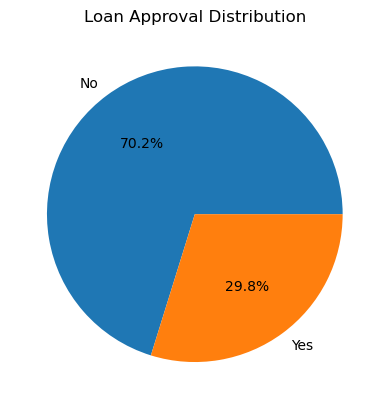

In [28]:
classes_cnt = df["Loan_Approved"].value_counts()
plt.pie(classes_cnt, labels=["No", "Yes"], autopct='%1.1f%%')
plt.title("Loan Approval Distribution")

[Text(0, 0, '621'), Text(0, 0, '379')]

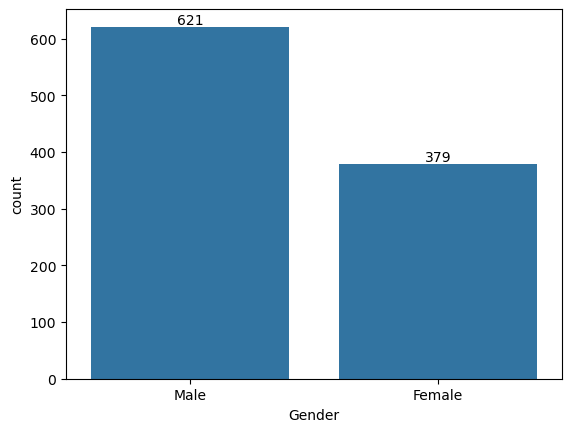

In [29]:
#Gender Distribution
gender_cnt = df['Gender'].value_counts()
ax= sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

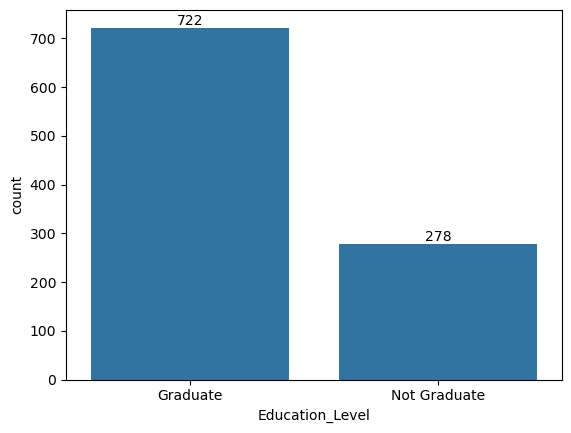

In [30]:
Education_cnt = df['Education_Level'].value_counts()
ax= sns.barplot(Education_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

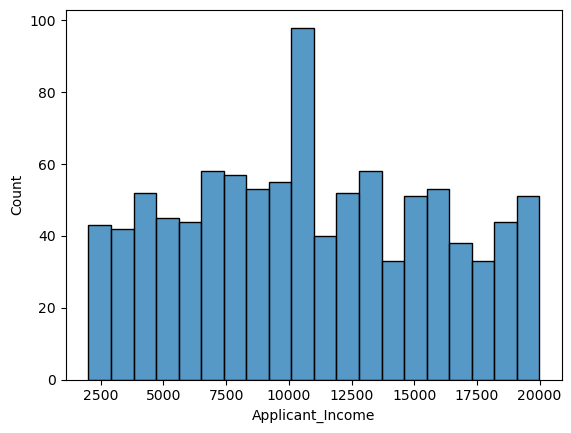

In [31]:
#Applicant Income Distribution
sns.histplot(
    data = df,
    x = 'Applicant_Income',
    bins = 20,
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

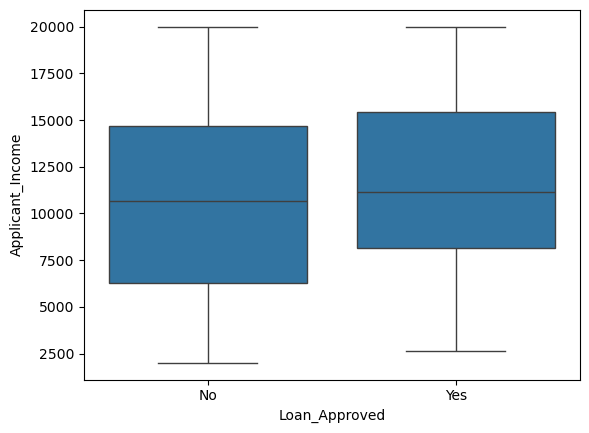

In [32]:
#outlier detection using boxplot
sns.boxplot(
    data = df,
    x = 'Loan_Approved',
    y = 'Applicant_Income'
)

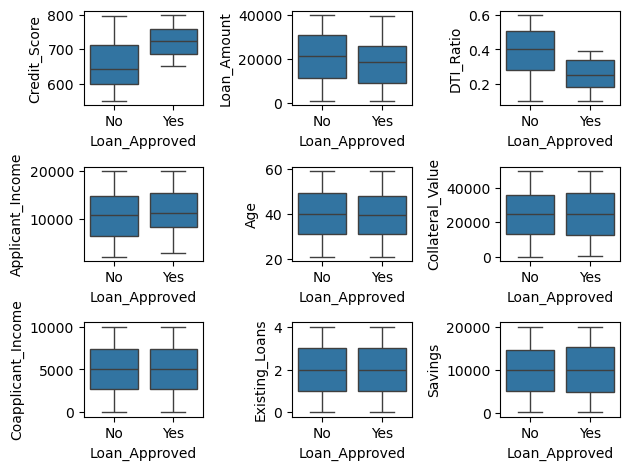

In [33]:
fig, axes = plt.subplots(3, 3)

sns.boxplot(data=df, x='Loan_Approved', y='Credit_Score', ax=axes[0, 0])

sns.boxplot(data=df, x='Loan_Approved', y='Loan_Amount', ax=axes[0, 1])

sns.boxplot(data=df, x='Loan_Approved', y='DTI_Ratio', ax=axes[0, 2])

sns.boxplot(data=df, x='Loan_Approved', y='Applicant_Income', ax=axes[1, 0])

sns.boxplot(data=df, x='Loan_Approved', y='Age', ax=axes[1, 1])

sns.boxplot(data=df, x='Loan_Approved', y='Collateral_Value', ax=axes[1, 2])

sns.boxplot(data=df, x='Loan_Approved', y='Coapplicant_Income', ax=axes[2, 0])

sns.boxplot(data=df, x='Loan_Approved', y='Existing_Loans', ax=axes[2, 1])

sns.boxplot(data=df, x='Loan_Approved', y='Savings', ax=axes[2, 2])

plt.tight_layout()
plt.show()

<Axes: xlabel='Credit_Score', ylabel='Count'>

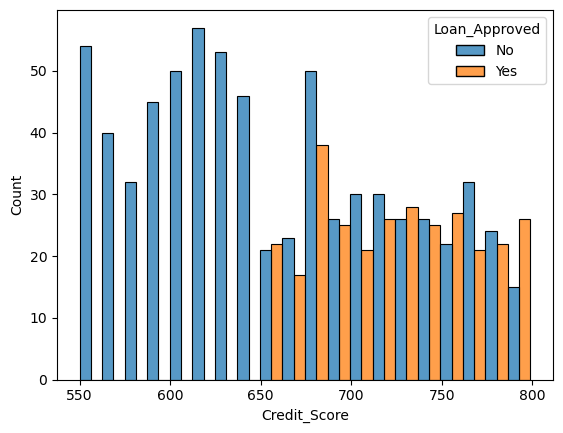

In [34]:
#credit_score
sns.histplot(
    data = df,
    x = 'Credit_Score',
    hue = 'Loan_Approved',
    multiple = 'dodge',
    bins = 20
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

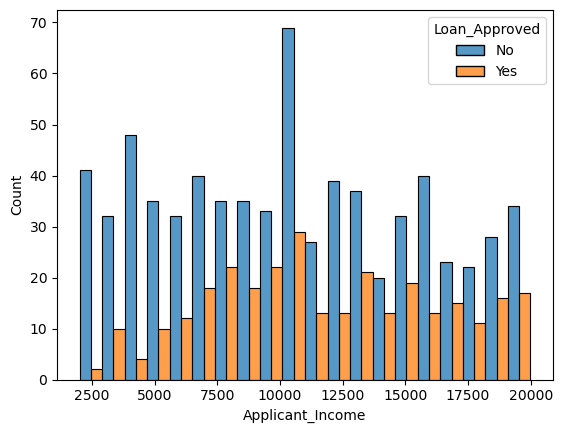

In [35]:
sns.histplot(
    data = df,
    x = 'Applicant_Income',
    hue = 'Loan_Approved',
    multiple = 'dodge',
    bins = 20
)

In [36]:
df = df.drop("Applicant_ID", axis=1)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

Feature Encoding


In [38]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [39]:


# Filter columns to only those that exist and haven't been encoded yet
cols = [col for col in [
    'Gender',
    'Employment_Status',
    'Marital_Status',
    'Property_Area',
    'Employer_Category',
    'Loan_Purpose'
] if col in df.columns]

if len(cols) > 0:
    ohe = OneHotEncoder(
        sparse_output=False,
        drop='first',
        handle_unknown='ignore'
    )

    # Encode categorical columns
    encoded = ohe.fit_transform(df[cols])

    # Convert encoded array into DataFrame
    encoded_df = pd.DataFrame(
        encoded,
        columns=ohe.get_feature_names_out(cols),
        index=df.index
    )

    # Remove original columns and add encoded columns
    df = pd.concat(
        [df.drop(columns=cols), encoded_df],
        axis=1
    )

In [40]:
df.sample(5)

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal
834,8359.0,7426.0,35.0,2.000000,565.0,1.0,0.347263,7933.0,33305.0,28453.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
652,12453.0,3124.0,51.0,0.000000,552.0,2.0,0.170000,8655.0,30669.0,11518.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
56,7675.0,6819.0,54.0,1.474737,752.0,1.0,0.570000,11530.0,27981.0,36245.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
361,12457.0,2844.0,47.0,1.000000,780.0,0.0,0.180000,3235.0,37174.0,20853.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
492,2504.0,1266.0,58.0,2.000000,681.0,4.0,0.230000,18276.0,42691.0,29906.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Correlation Heatmap

In [41]:
num_cols = df.select_dtypes(include = 'number')
corr_matrix = num_cols.corr()


In [42]:
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,0.004845,-0.036260,-0.025011,0.102589,-0.044639,-0.011995,-0.083398,0.032794,0.074209,-0.031234
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,-0.010058,0.030045,-0.001146,0.037640,0.004312,-0.047929,-0.020148,0.028000,0.016022,0.059549
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,0.003100,-0.025661,-0.066041,0.021232,-0.012960,0.072462,-0.025521,-0.006283,0.029865,0.037293
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.032278,0.024082,-0.009250,-0.018757,0.030197,-0.054147,-0.043685,-0.044642,0.027343,-0.005785
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,-0.006946,0.004445,-0.007076,0.066736,-0.000049,-0.046087,-0.030142,0.026013,-0.008658,0.015324
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.053971,0.035629,-0.009642,0.030520,-0.019306,0.045391,-0.025228,-0.010035,0.001777,0.023212
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,0.044898,-0.006156,-0.007214,0.002090,-0.003506,0.026018,-0.020907,0.040432,-0.014125,-0.036648
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,0.005438,0.016833,-0.011683,0.004381,-0.030208,0.027178,-0.009133,0.032558,-0.012217,-0.028948
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.020061,0.007975,0.035760,-0.013464,-0.014480,-0.009655,0.031112,0.040406,-0.050975,-0.007120
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,0.040206,-0.050076,0.013108,-0.025975,0.013923,-0.026566,-0.006788,-0.006119,-0.000930,0.032498


In [43]:
num_cols.corr()["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

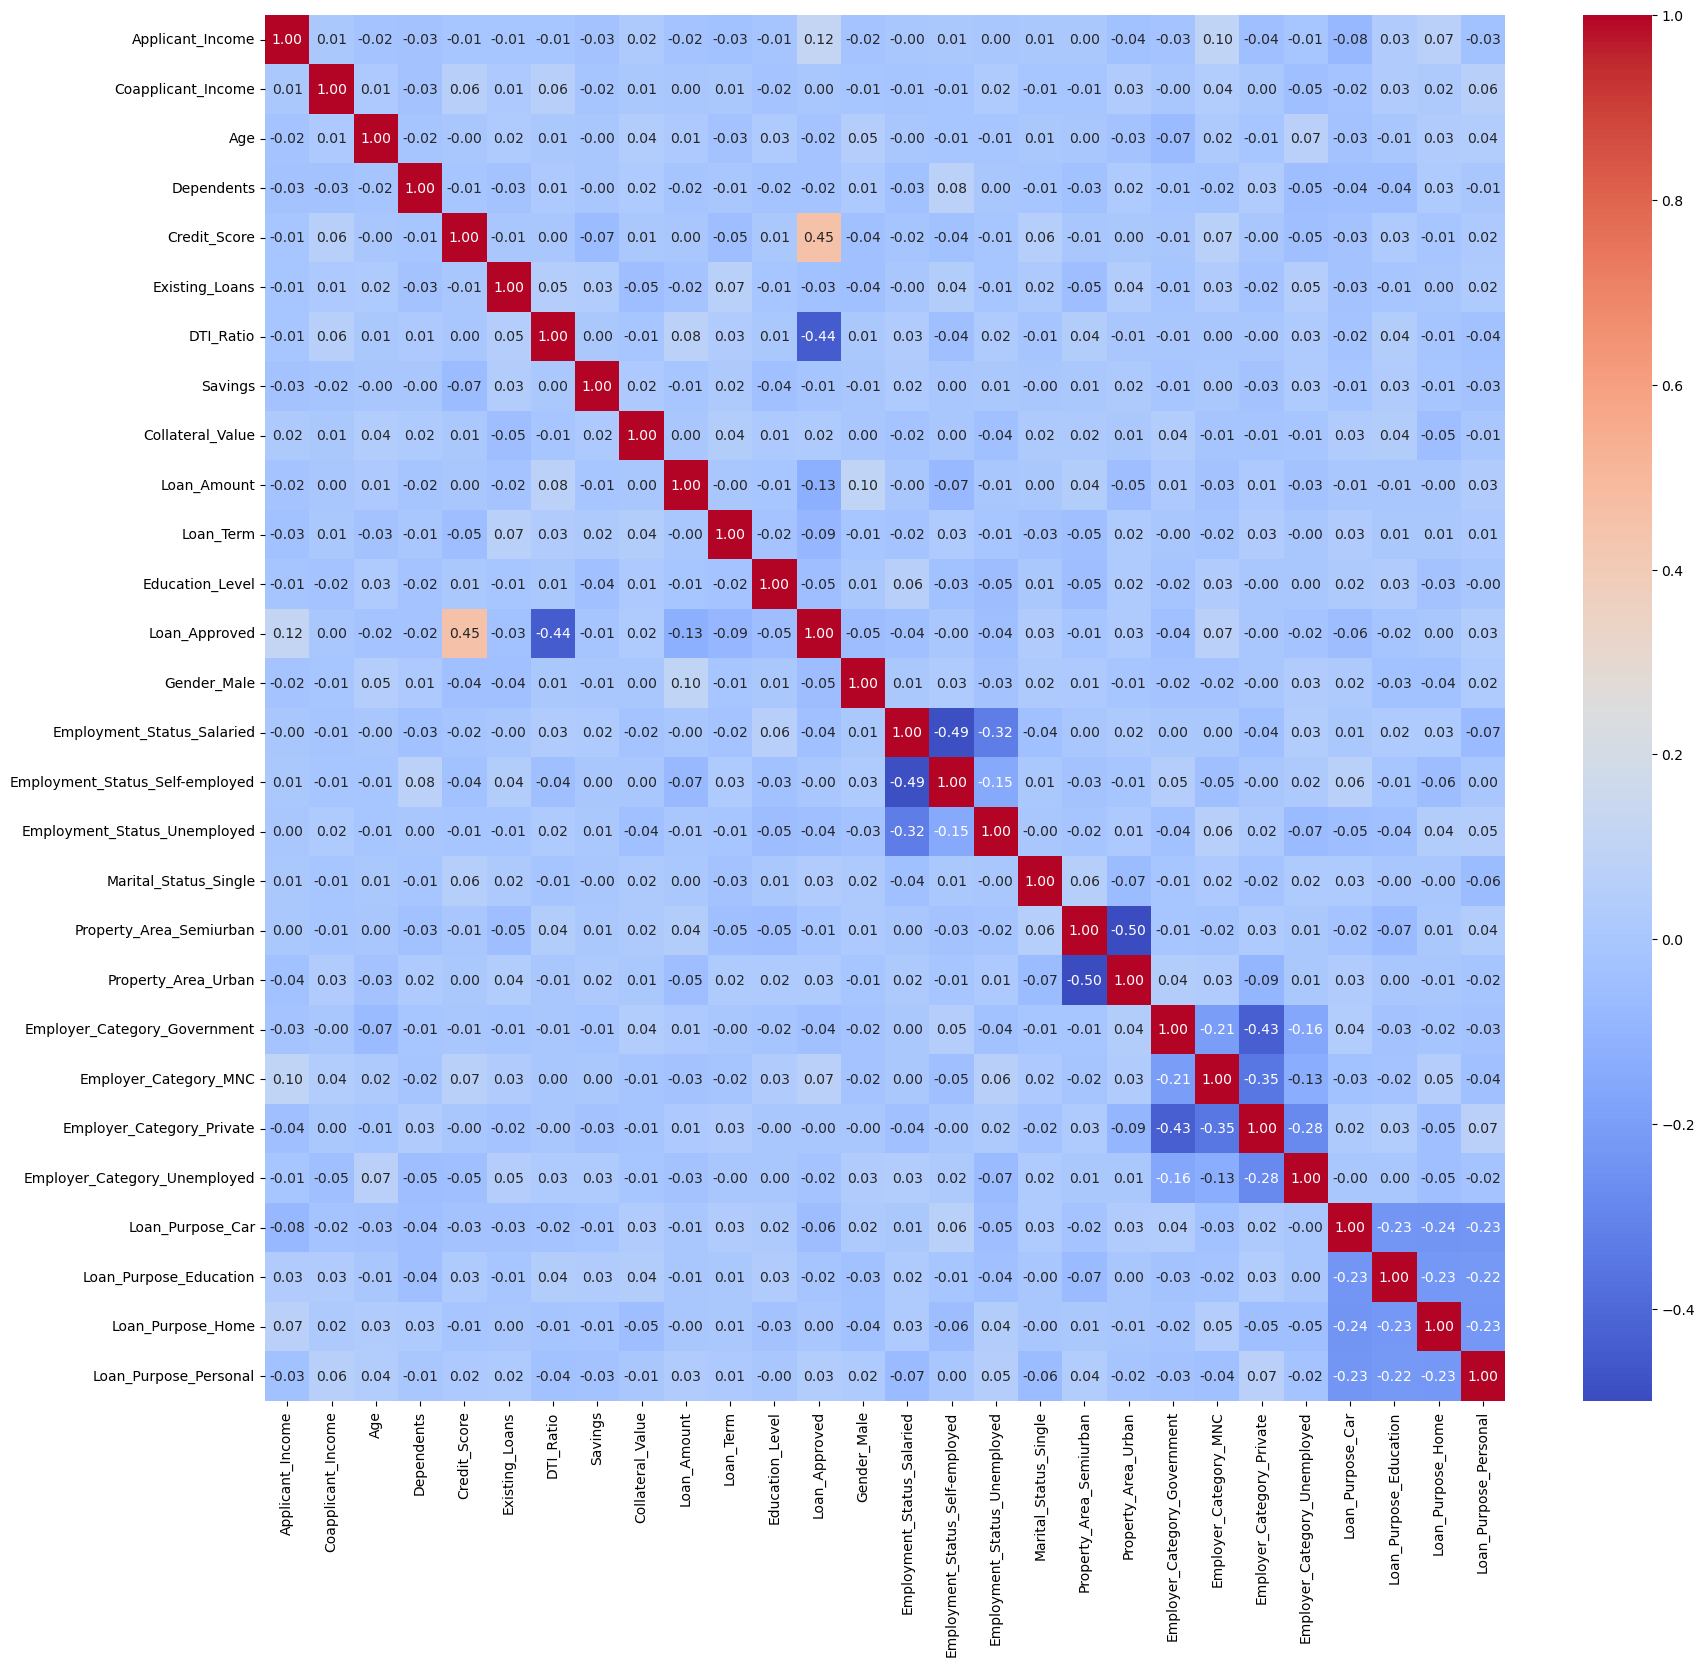

In [44]:
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt = '.2f')


plt.show()

In [45]:
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [ ]:
from sklearn.

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [50]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [52]:
X_train_scaler

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -4.80384461e-01, -4.88252079e-01, -4.64548675e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -4.80384461e-01,  2.04812236e+00, -4.64548675e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
        -4.80384461e-01, -4.88252079e-01,  2.15262696e+00],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
         2.08166600e+00, -4.88252079e-01, -4.64548675e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -4.80384461e-01,  2.04812236e+00, -4.64548675e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
        -4.80384461e-01, -4.88252079e-01, -4.64548675e-01]],
      shape=(800, 27))

In [ ]:
# logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
logreg = LogisticRegression()    

logreg.fit(X_train_scaler, y_train)
y_pred = logreg.predict(X_test_scaler)

print("Confusion matrix : " , confusion_matrix(y_test, y_pred))
print("Accuracy : " , accuracy_score(y_test, y_pred))
print("Precision : " , precision_score(y_test, y_pred))
print("Recall : " , recall_score(y_test, y_pred))
print("F1 Score : " , f1_score(y_test, y_pred))

Confusion matrix :  [[126  13]
 [ 14  47]]
Accuracy :  0.865
Precision :  0.7833333333333333
Recall :  0.7704918032786885
F1 Score :  0.7768595041322314


In [ ]:
#knn classifier
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust the number of neighbors as needed
knn.fit(X_train_scaler, y_train)
y_pred_knn = knn.predict(X_test_scaler)

print("Confusion matrix : " , confusion_matrix(y_test, y_pred_knn))
print("Accuracy : " , accuracy_score(y_test, y_pred_knn))
print("Precision : " , precision_score(y_test, y_pred_knn))
print("Recall : " , recall_score(y_test, y_pred_knn))
print("F1 Score : " , f1_score(y_test, y_pred_knn))

Confusion matrix :  [[120  19]
 [ 29  32]]
Accuracy :  0.76
Precision :  0.6274509803921569
Recall :  0.5245901639344263
F1 Score :  0.5714285714285714


In [68]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train_scaler, y_train)
y_pred = nb.predict(X_test_scaler)


print("Confusion matrix : " , confusion_matrix(y_test, y_pred))
print("Accuracy : " , accuracy_score(y_test, y_pred))
print("Precision : " , precision_score(y_test, y_pred))
print("Recall : " , recall_score(y_test, y_pred))
print("F1 Score : " , f1_score(y_test, y_pred))

Confusion matrix :  [[128  11]
 [ 16  45]]
Accuracy :  0.865
Precision :  0.8035714285714286
Recall :  0.7377049180327869
F1 Score :  0.7692307692307693


Best Precision score as far is obtained by Naive Bayes 

Let's try more feature engineering

In [ ]:
df["Credit_Score_sq"] = df["Credit_Score"] ** 2
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2

In [71]:
X = df.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#scaling data
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [73]:
#Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
logreg = LogisticRegression()    

logreg.fit(X_train_scaler, y_train)
y_pred = logreg.predict(X_test_scaler)

print("Confusion matrix : " , confusion_matrix(y_test, y_pred))
print("Accuracy : " , accuracy_score(y_test, y_pred))
print("Precision : " , precision_score(y_test, y_pred))
print("Recall : " , recall_score(y_test, y_pred))
print("F1 Score : " , f1_score(y_test, y_pred))


Confusion matrix :  [[126  13]
 [ 12  49]]
Accuracy :  0.875
Precision :  0.7903225806451613
Recall :  0.8032786885245902
F1 Score :  0.7967479674796748


In [79]:
# knn classifier

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=11)  # You can adjust the number of neighbors as needed
knn.fit(X_train_scaler, y_train)
y_pred_knn = knn.predict(X_test_scaler)

print("Confusion matrix : " , confusion_matrix(y_test, y_pred_knn))
print("Accuracy : " , accuracy_score(y_test, y_pred_knn))
print("Precision : " , precision_score(y_test, y_pred_knn))
print("Recall : " , recall_score(y_test, y_pred_knn))
print("F1 Score : " , f1_score(y_test, y_pred_knn))

Confusion matrix :  [[129  10]
 [ 30  31]]
Accuracy :  0.8
Precision :  0.7560975609756098
Recall :  0.5081967213114754
F1 Score :  0.6078431372549019


In [80]:
#Naive Bayes Classifier

from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train_scaler, y_train)
y_pred = nb.predict(X_test_scaler)


print("Confusion matrix : " , confusion_matrix(y_test, y_pred))
print("Accuracy : " , accuracy_score(y_test, y_pred))
print("Precision : " , precision_score(y_test, y_pred))
print("Recall : " , recall_score(y_test, y_pred))
print("F1 Score : " , f1_score(y_test, y_pred))

Confusion matrix :  [[126  13]
 [ 14  47]]
Accuracy :  0.865
Precision :  0.7833333333333333
Recall :  0.7704918032786885
F1 Score :  0.7768595041322314
